Клинические признаки 1-10 и 34 - Клинические признаки — это проявления заболевания или патологического состояния, которые выявляются при клиническом обследовании пациента. Они служат основой для постановки диагноза и определения прогноза заболевания.

Гистопатологические признаки - все остальное - Гистопатологические признаки — это морфологические изменения в тканях, которые выявляет патологоанатом при микроскопическом исследовании образцов тканей (биоптатов).

Здесь 0 означает, что функция отсутствовала, 3 — максимально возможное количество, а 1 и 2 — промежуточные значения.

- Psoriasis — псориаз
- Seborrheic dermatitis — себорейный дерматит
- Lichen planus — красный плоский лишай
- Pityriasis rosea — розовый лишай
- Chronic dermatitis — хронический дерматит
- Pityriasis rubra pilaris — красный волосяной лишай (PRP)

In [ ]:
!pip install factor_analyzer -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install adjustText -q

In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from factor_analyzer import FactorAnalyzer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [ ]:
path = kagglehub.dataset_download("olcaybolat1/dermatology-dataset-classification")
print("Path:", path)
pd.set_option("display.max_columns", None)
print(os.listdir(path))

100%|██████████| 5.13k/5.13k [00:00<00:00, 4.27MB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/olcaybolat1/dermatology-dataset-classification/versions/5
['dermatology_database_1.csv']


| №  | Признак (EN)                             | Перевод (RU)                                  | Описание                                                 |
| -- | ---------------------------------------- | --------------------------------------------- | -------------------------------------------------------- |
| 1  | erythema                                 | эритема                                       | Покраснение кожи из-за воспаления или расширения сосудов |
| 2  | scaling                                  | шелушение                                     | Отслаивание верхнего слоя кожи                           |
| 3  | definite borders                         | чёткие границы                                | Ясно очерченные края поражённого участка                 |
| 4  | itching                                  | зуд                                           | Ощущение, вызывающее желание чесать кожу                 |
| 5  | koebner phenomenon                       | феномен Кебнера                               | Появление высыпаний на месте травмы кожи                 |
| 6  | polygonal papules                        | полигональные папулы                          | Многоугольные плотные кожные узелки                      |
| 7  | follicular papules                       | фолликулярные папулы                          | Узелки, связанные с волосяными фолликулами               |
| 8  | oral mucosal involvement                 | поражение слизистой рта                       | Вовлечение слизистой оболочки полости рта                |
| 9  | knee and elbow involvement               | поражение коленей и локтей                    | Локализация высыпаний на этих суставах                   |
| 10 | scalp involvement                        | поражение кожи головы                         | Вовлечение волосистой части головы                       |
| 11 | family history                           | семейный анамнез                              | Наличие заболевания у родственников                      |
| 12 | melanin incontinence                     | недержание меланина                           | Выход меланина в дерму при повреждении кожи              |
| 13 | eosinophils in the infiltrate            | эозинофилы в инфильтрате                      | Наличие эозинофилов в воспалительном инфильтрате         |
| 14 | PNL infiltrate                           | нейтрофильный инфильтрат                      | Присутствие полиморфноядерных лейкоцитов                 |
| 15 | fibrosis of the papillary dermis         | фиброз сосочкового слоя дермы                 | Уплотнение соединительной ткани                          |
| 16 | exocytosis                               | экзоцитоз                                     | Миграция клеток воспаления в эпидермис                   |
| 17 | acanthosis                               | акантоз                                       | Утолщение эпидермиса                                     |
| 18 | hyperkeratosis                           | гиперкератоз                                  | Утолщение рогового слоя кожи                             |
| 19 | parakeratosis                            | паракератоз                                   | Нарушение ороговения с сохранением ядер                  |
| 20 | clubbing of the rete ridges              | булавовидное утолщение эпидермальных выростов | Расширение эпидермальных гребней                         |
| 21 | elongation of the rete ridges            | удлинение эпидермальных выростов              | Удлинение эпидермальных тяжей                            |
| 22 | thinning of the suprapapillary epidermis | истончение надсосочкового эпидермиса          | Уменьшение толщины эпидермиса над сосочками              |
| 23 | spongiform pustule                       | спонгиозные пустулы                           | Пузырьки с жидкостью в эпидермисе                        |
| 24 | munro microabcess                        | микроабсцессы Мунро                           | Скопления нейтрофилов в роговом слое                     |
| 25 | focal hypergranulosis                    | очаговый гипергранулёз                        | Локальное утолщение зернистого слоя                      |
| 26 | disappearance of the granular layer      | исчезновение зернистого слоя                  | Отсутствие зернистого слоя эпидермиса                    |
| 27 | vacuolisation and damage of basal layer  | вакуолизация и повреждение базального слоя    | Разрушение клеток базального слоя                        |
| 28 | spongiosis                               | спонгиоз                                      | Межклеточный отёк эпидермиса                             |
| 29 | saw-tooth appearance of retes            | «пилообразные» выросты                        | Характерная форма эпидермальных тяжей                    |
| 30 | follicular horn plug                     | роговые пробки фолликулов                     | Закупорка фолликулов кератином                           |
| 31 | perifollicular parakeratosis             | перифолликулярный паракератоз                 | Паракератоз вокруг фолликулов                            |
| 32 | inflammatory mononuclear infiltrate      | мононуклеарный инфильтрат                     | Скопление лимфоцитов и моноцитов                         |
| 33 | band-like infiltrate                     | ленточный инфильтрат                          | Плотный слой воспалительных клеток                       |
| 34 | age                                      | возраст                                       | Возраст пациента (числовой признак)                      |


In [ ]:
file_path = os.path.join(path, "dermatology_database_1.csv")
df = pd.read_csv(file_path)

df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_infiltrate,PNL_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


In [ ]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_infiltrate,PNL_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,0.125683,0.404372,0.139344,0.546448,0.336066,1.368852,1.956284,0.527322,1.289617,0.663934,0.991803,0.633880,0.295082,0.363388,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,0.331946,0.869818,0.411790,0.815451,0.853139,1.104418,0.712512,0.757116,0.917562,1.056829,1.162161,1.034924,0.670578,0.759721,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [ ]:
df_features = df.drop(columns=['class', 'family_history'])
df_features = df_features.replace("?", np.nan)
df_features = df_features.apply(pd.to_numeric)
df_features['age'] = df_features['age'].fillna(df_features['age'].mean())

In [ ]:
# df_features.isnull().sum()

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)

In [ ]:
kmo_all, kmo_model = calculate_kmo(df_scaled)
print("KMO:", kmo_model)

chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("Bartlett p-value:", p_value)

KMO: 0.9062033885118154
Bartlett p-value: 0.0


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


1. KMO (0.907)

Переменные имеют высокую общую факторную структуру и хорошо подходят для факторного анализа.

2. Тест Бартлетта (p-value = 0.0)

p-value < 0.05 -> между переменными есть значимые корреляции

In [ ]:
# 4.на основе КМ сделать гипотезы о количестве и связях факторов с переменными

In [ ]:
# # корреляционная матрица
# corr_matrix = pd.DataFrame(df_scaled, columns=df_features.columns).corr()

# # визуализация с числами
# plt.figure(figsize=(12, 10))
# sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f", annot_kws={"size": 6})
# plt.title("Correlation Matrix Heatmap")
# plt.show()

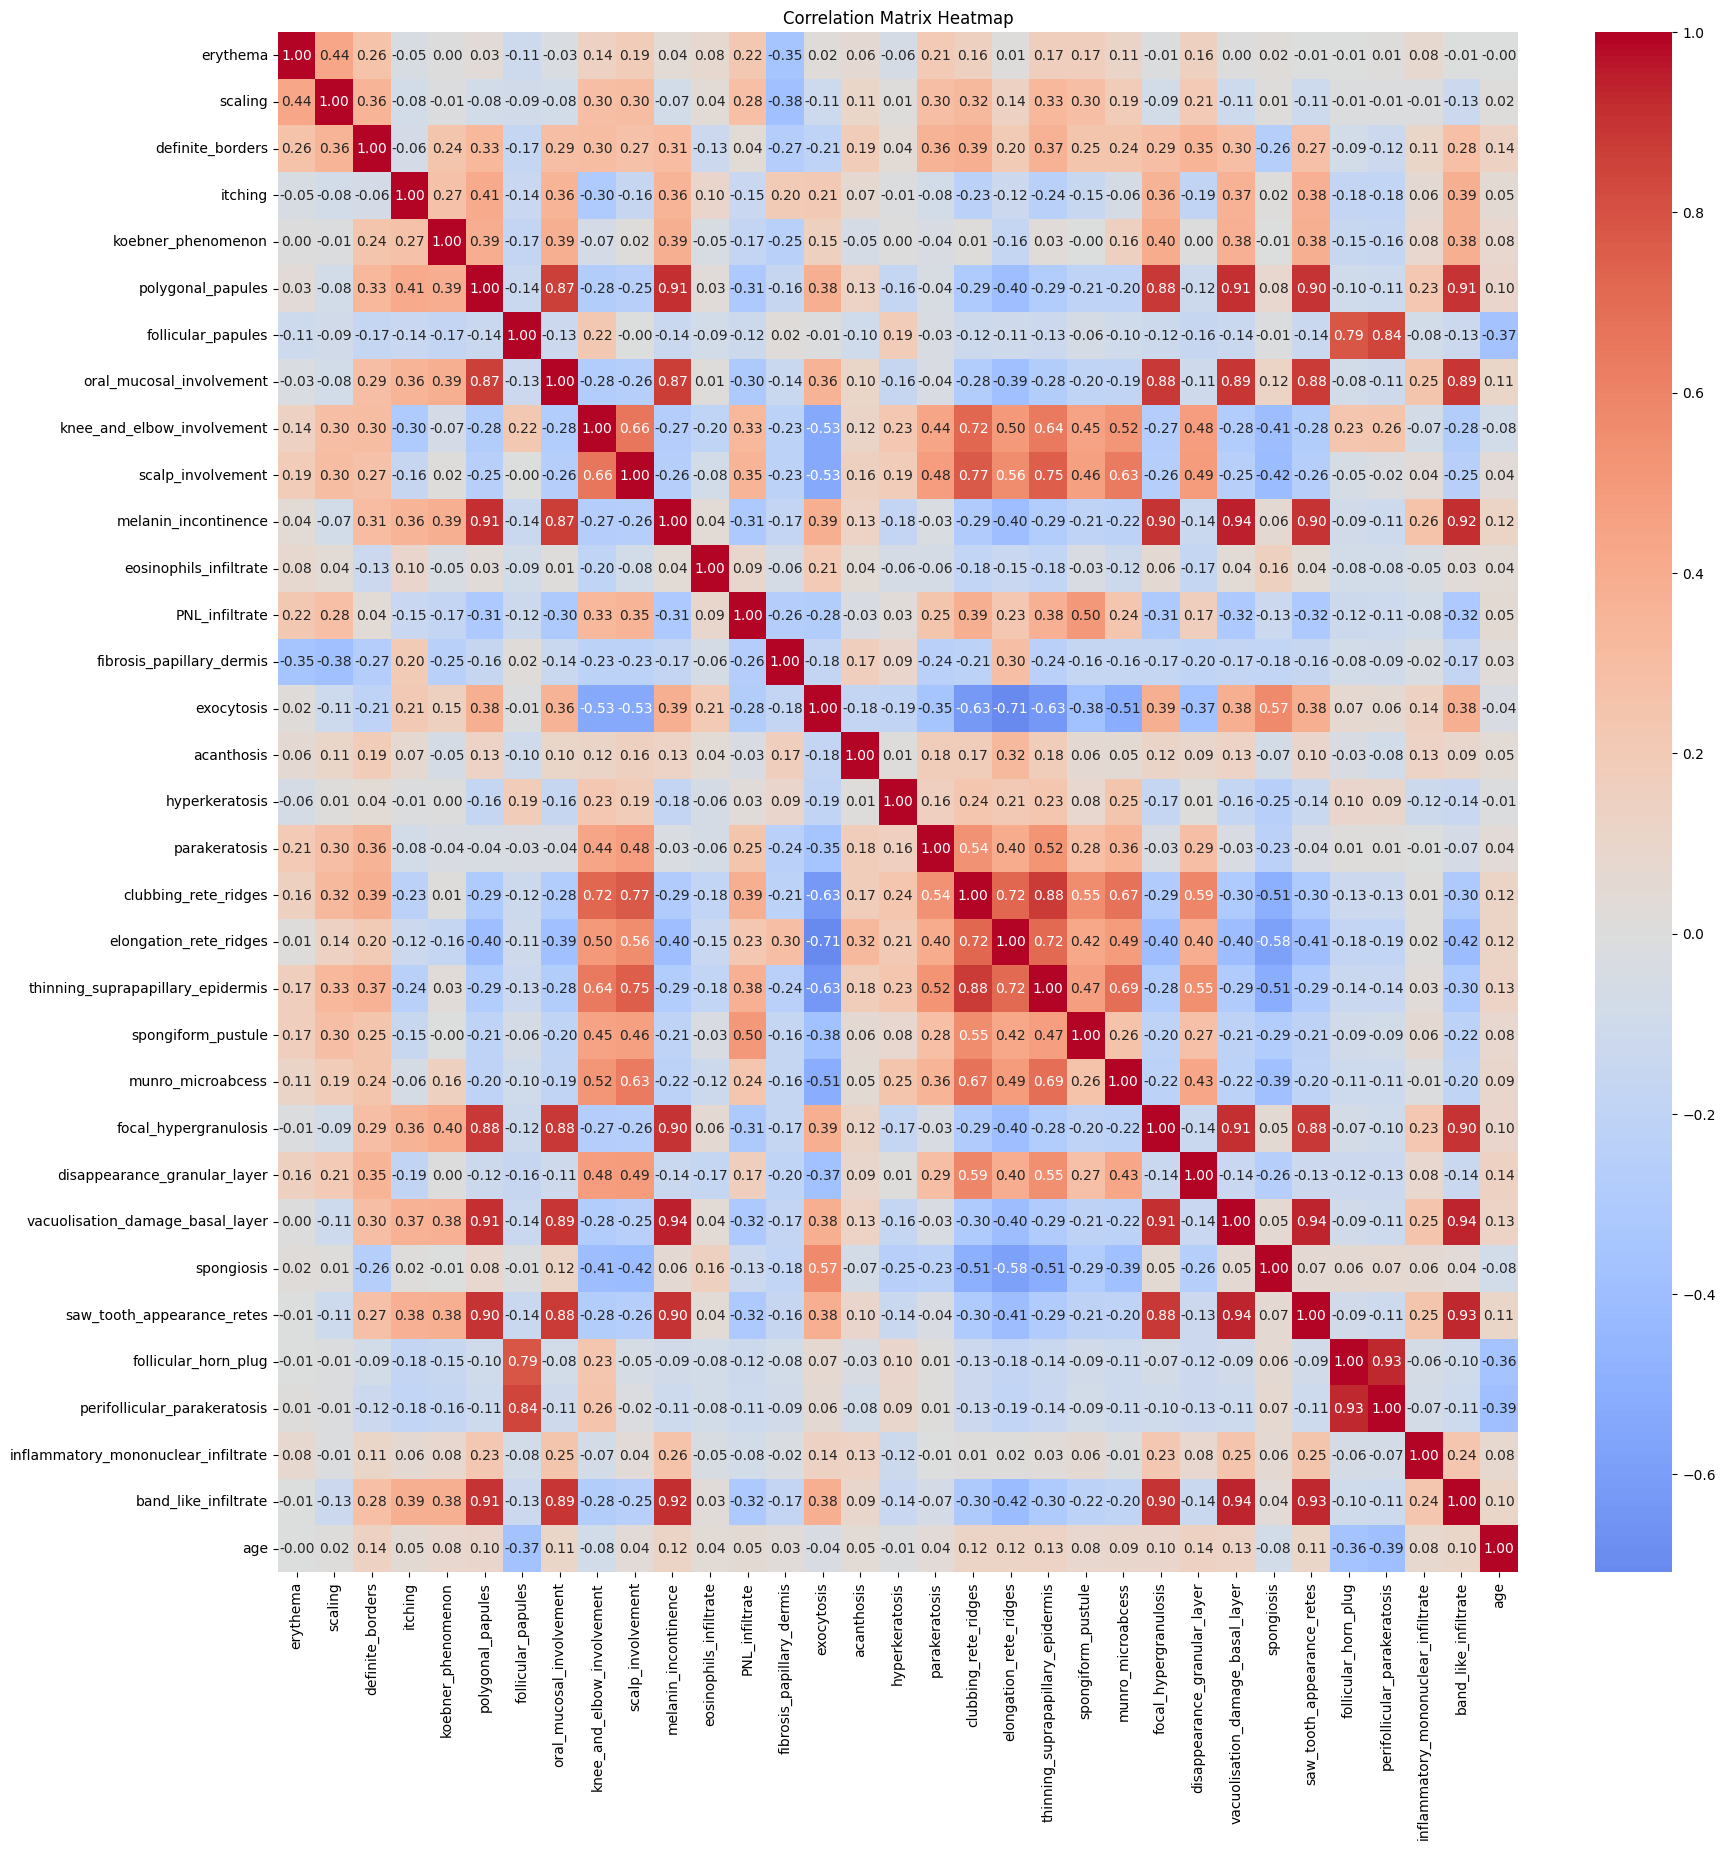

In [ ]:
# корреляционная матрица
corr_matrix = pd.DataFrame(df_scaled, columns=df_features.columns).corr()

# визуализация с числами
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

1 фактор
- oral_mucosal_involvement
- focal_hypergranulosis
- polugonal_papules
- melanin_incontience
- vacuolisation_damage_basal_layer
- saw_tooth_appearance_retes
- band_like_infiltrate
- exocytosis
- spongiosis

2 фактор
- folicular_papules
- folicular_horn_plug
- perifollicular_parakeratosis

3 фактор
- hyperkeratosis
- spongiform_pustule
- elongation_rete_ridges
- knee_and_elbow_involvement
- munro_microabcess
- scalp_involvement
- clubbing_rete_ridges
- thinning_suprapapillary_epidermis
- parakeratosis
- disappearance_granular_layer

4 фактор
- erythema
- scaling
- PNL_infiltrate
- definite_borders

In [ ]:
# sns.clustermap(df_features.corr(), cmap='coolwarm', figsize=(12, 12))

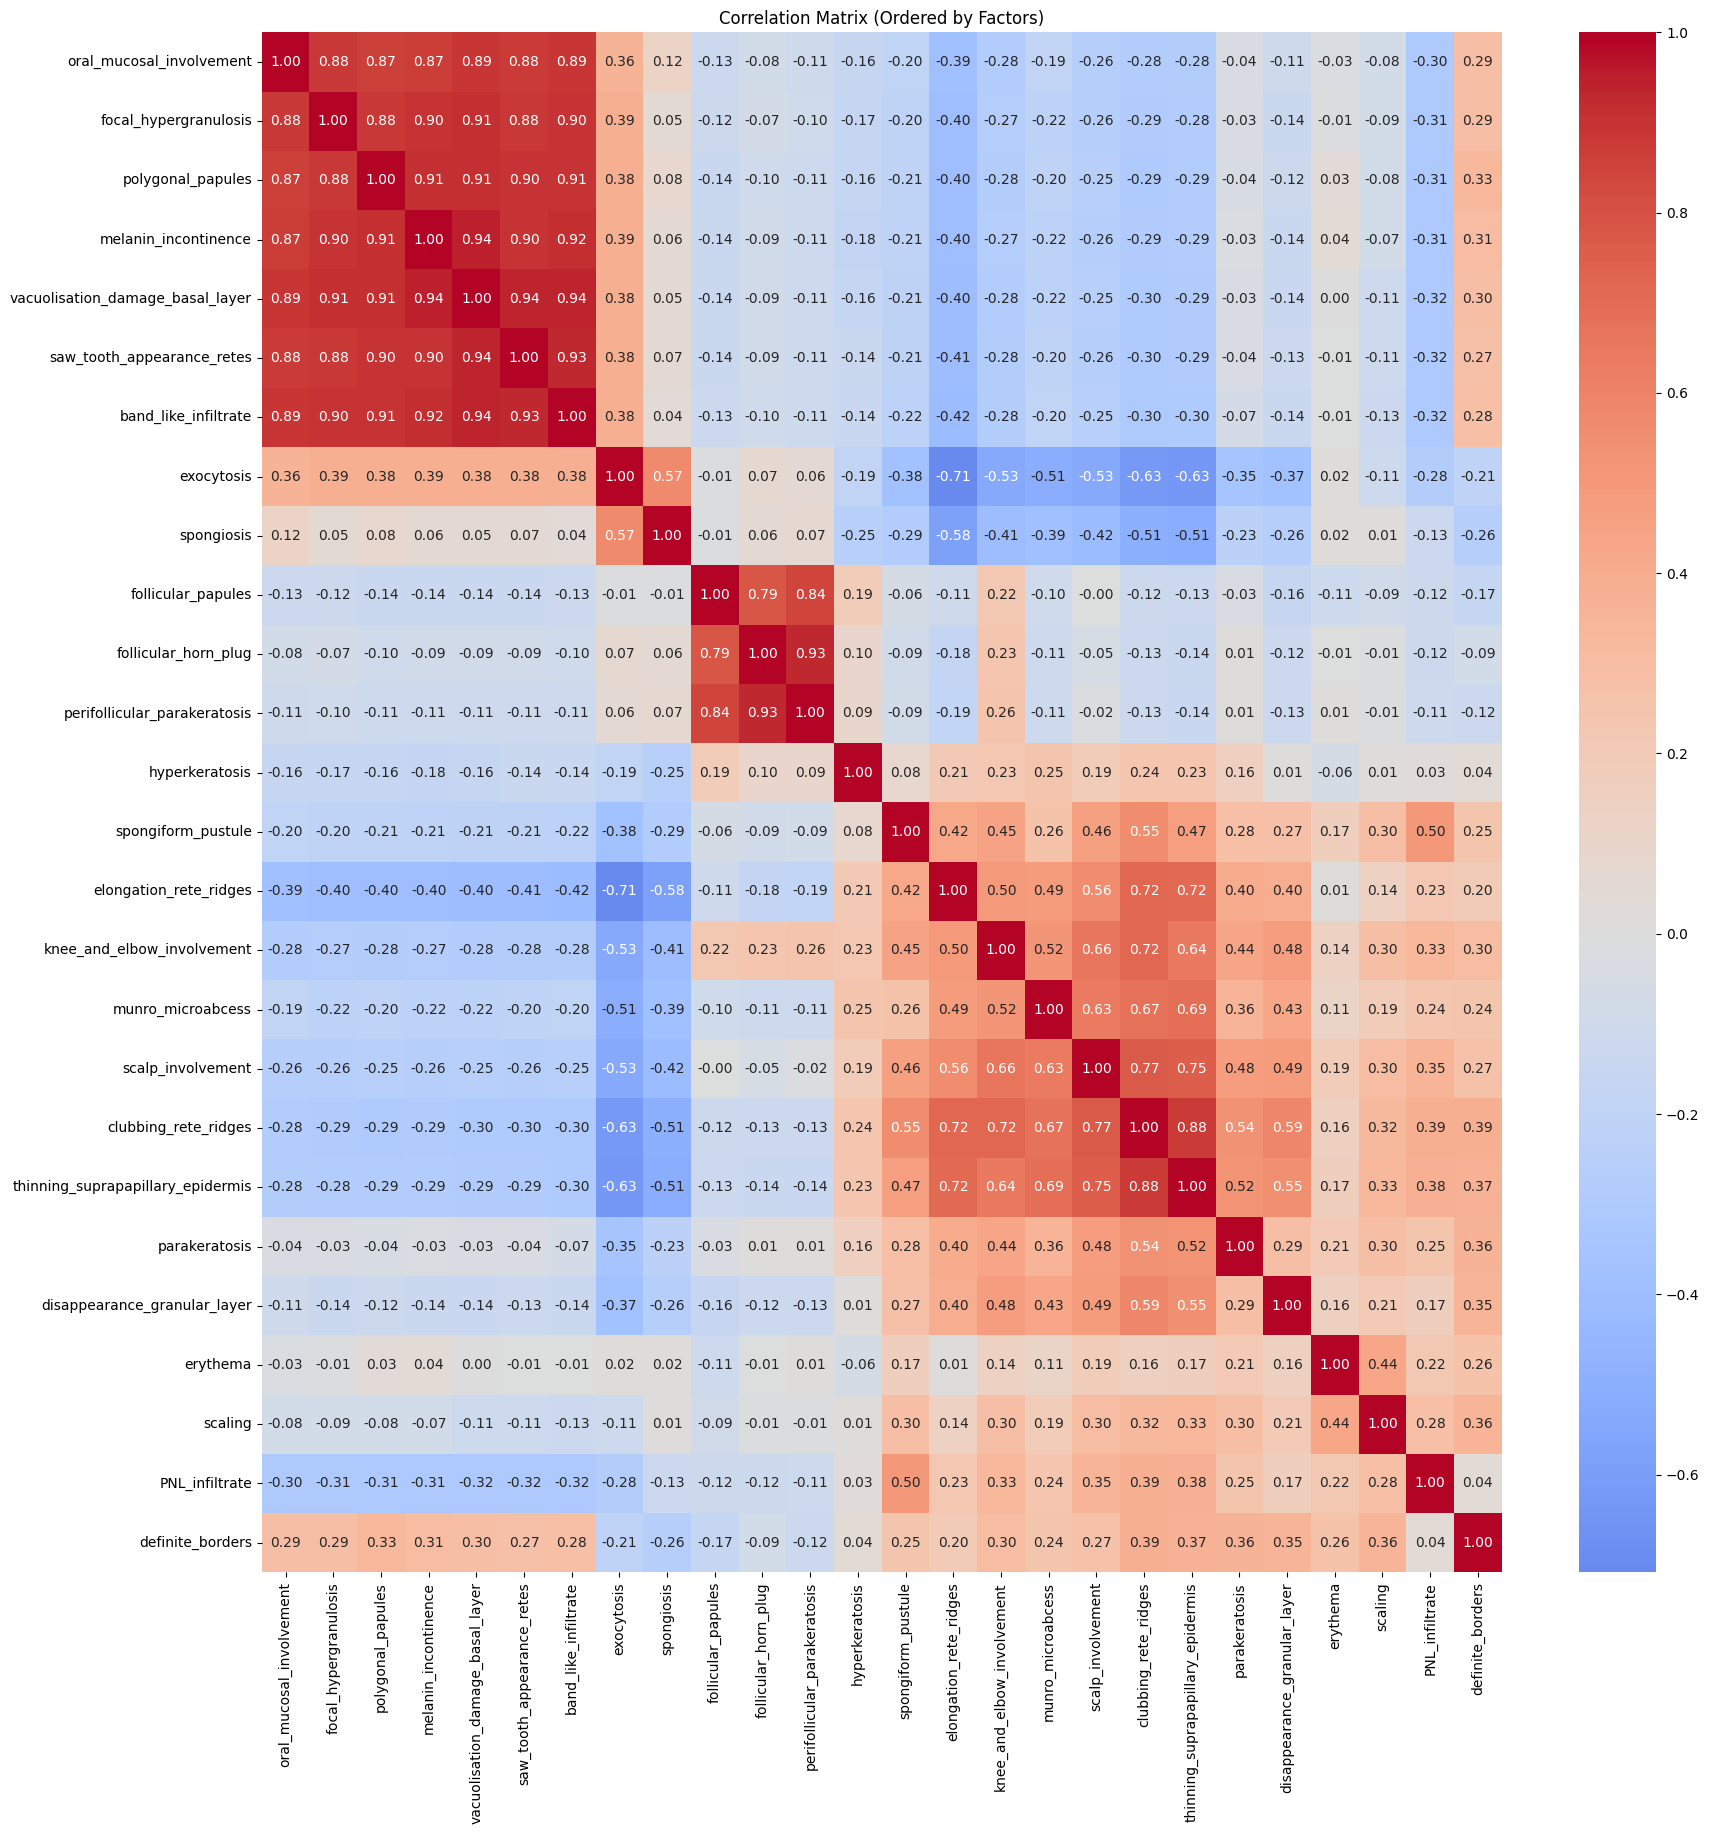

In [ ]:
factor_1 = [
    'oral_mucosal_involvement',
    'focal_hypergranulosis',
    'polygonal_papules',
    'melanin_incontinence',
    'vacuolisation_damage_basal_layer',
    'saw_tooth_appearance_retes',
    'band_like_infiltrate',
    'exocytosis',
    'spongiosis'
]

factor_2 = [
    'follicular_papules',
    'follicular_horn_plug',
    'perifollicular_parakeratosis'
]

factor_3 = [
    'hyperkeratosis',
    'spongiform_pustule',
    'elongation_rete_ridges',
    'knee_and_elbow_involvement',
    'munro_microabcess',
    'scalp_involvement',
    'clubbing_rete_ridges',
    'thinning_suprapapillary_epidermis',
    'parakeratosis',
    'disappearance_granular_layer'
]

factor_4 = [
    'erythema',
    'scaling',
    'PNL_infiltrate',
    'definite_borders'
]

# объединяем порядок
ordered_features = factor_1 + factor_2 + factor_3 + factor_4

corr_matrix = pd.DataFrame(df_scaled, columns=df_features.columns)[ordered_features].corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix (Ordered by Factors)")
plt.show()


Анализ корреляционной матрицы показал наличие выраженных блоков взаимосвязанных признаков, что позволяет предположить существование нескольких скрытых латентных факторов, отражающих различные клинико-морфологические паттерны дерматологических заболеваний.

Высокие внутригрупповые корреляции признаков и относительная независимость между отдельными группами свидетельствуют о наличии приблизительно 4-5 факторов.



Фактор 1 — лихеноидно-воспалительный паттерн
Отражает иммунное воспаление и дегенеративные изменения базального слоя эпидермиса, характерные для красного плоского лишая.


Фактор 2 — фолликулярно-кератотический паттерн
Связан с нарушением ороговения и поражением волосяных фолликулов, характерным для pityriasis rubra pilaris.


Фактор 3 — псориатический гиперпролиферативный паттерн
Описывает ускоренную пролиферацию эпидермиса и воспалительные изменения, типичные для псориаза.


Фактор 4 — поверхностный воспалительный паттерн
Объединяет внешние клинические проявления воспаления кожи: эритему, шелушение и чёткие границы очагов.


Фактор 5 — неспецифический воспалительно-экссудативный паттерн
Включает признаки острого воспаления и межклеточного отёка эпидермиса (spongiosis, exocytosis), характерные для экзематозных и дерматитоподобных процессов.

In [ ]:
# 5. Показать статистическое распределение признаков

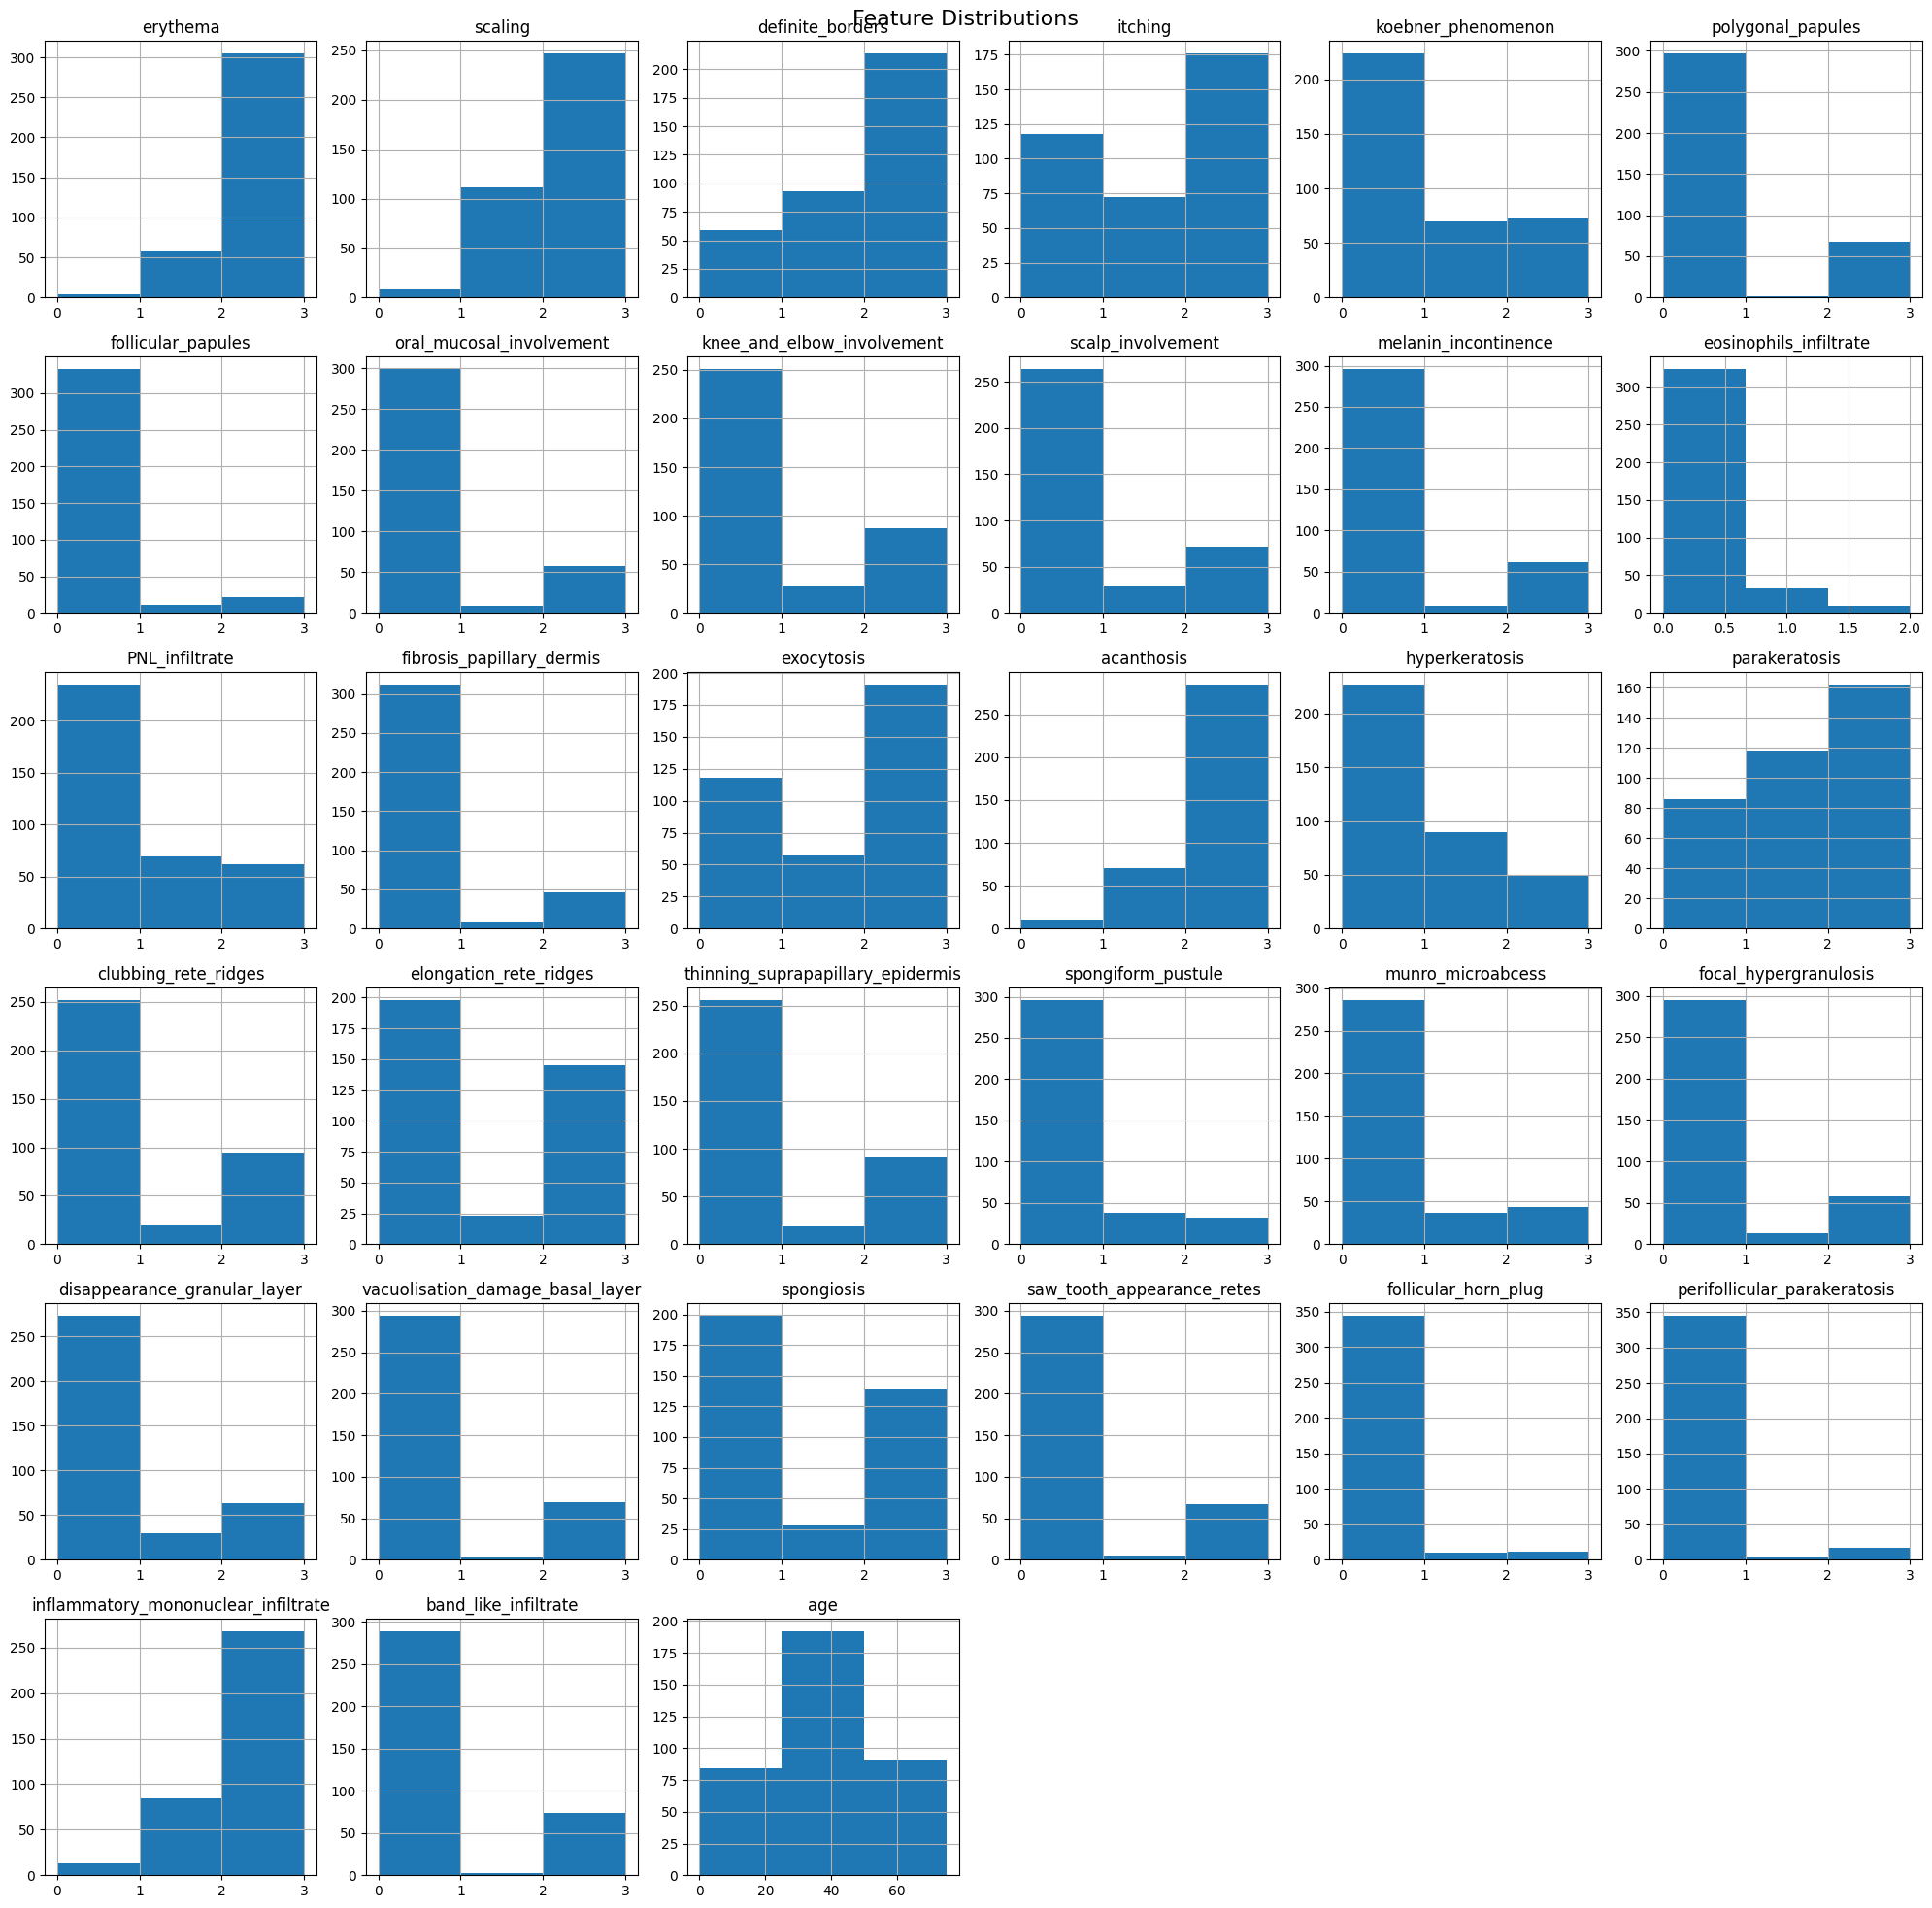

In [ ]:
df_features.hist(figsize=(20, 20), bins=3)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Провести PCA, выбрать число компонентов на основе scree plot, сделать визуализацию векторов

In [ ]:
pca = PCA()
pca.fit(df_scaled)

PCA()

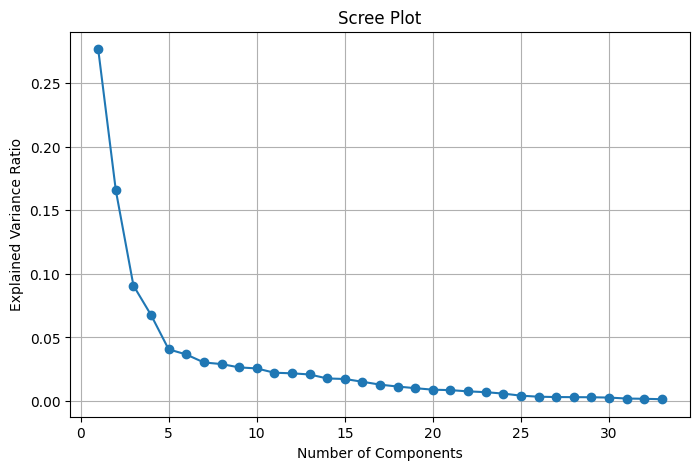

In [ ]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.show()

In [ ]:
pca_2 = PCA(n_components=5)
df_pca = pca_2.fit_transform(df_scaled)

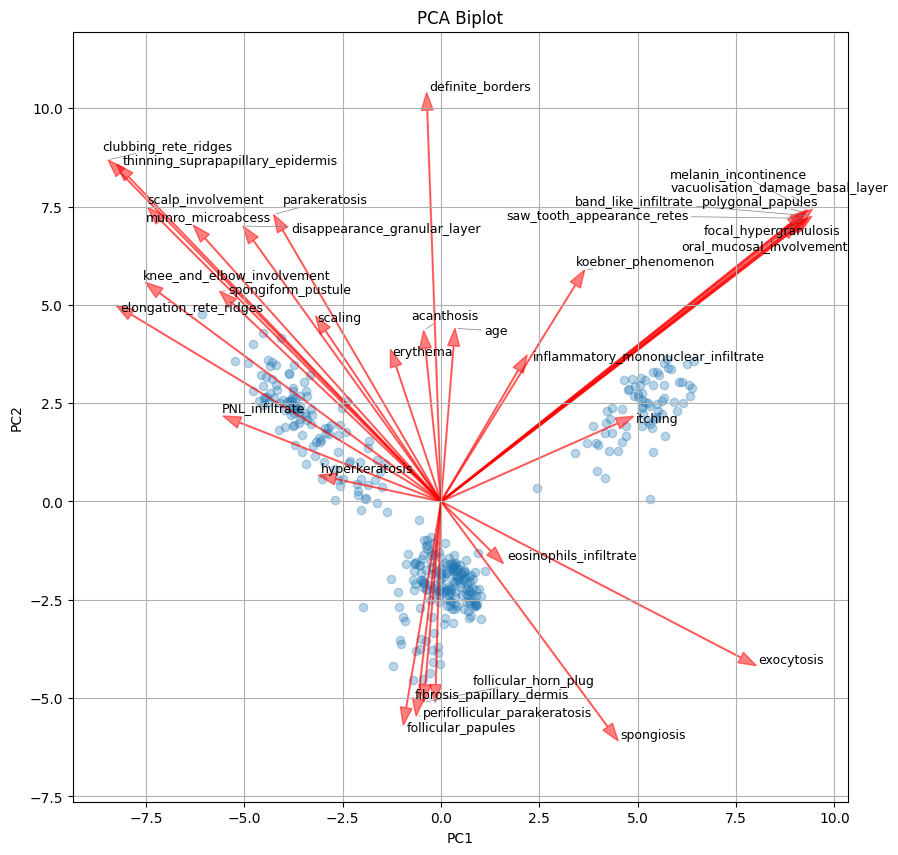

In [ ]:
loadings = pca_2.components_.T

scale = 35

plt.figure(figsize=(10, 10))

# точки объектов
plt.scatter(df_pca[:, 0], df_pca[:, 1], alpha=0.3)

texts = []

# векторы признаков
for i, feature in enumerate(df_features.columns):

    x = loadings[i, 0] * scale
    y = loadings[i, 1] * scale

    plt.arrow(
        0, 0,
        x, y,
        color='r',
        alpha=0.5,
        width=0.02,
        head_width=0.3,
        length_includes_head=True
    )

    texts.append(
        plt.text(
            x,
            y,
            feature,
            fontsize=9
        )
    )

# автораздвижение подписей
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=0.5
    )
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")

plt.grid(True)
plt.axis('equal')

plt.show()

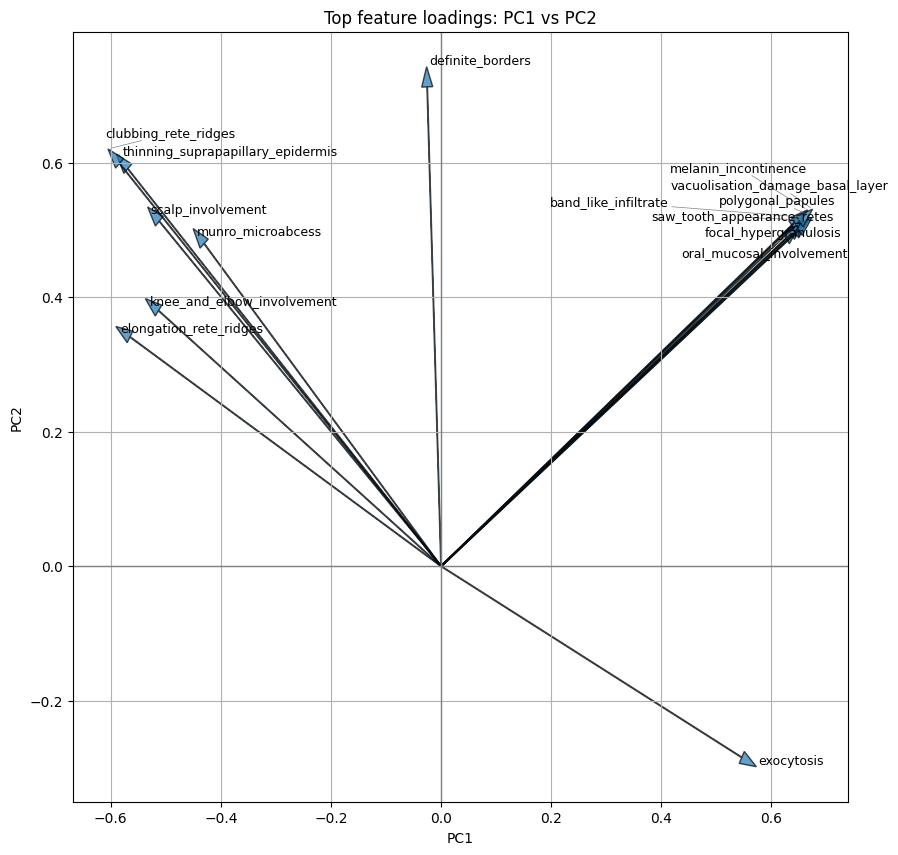

In [ ]:
loadings = pca_2.components_.T
features = df_features.columns

pc_x = 0
pc_y = 1

importance = np.sqrt(loadings[:, pc_x]**2 + loadings[:, pc_y]**2)

top_n = 15
idx = np.argsort(importance)[-top_n:]

scale = 2.5

plt.figure(figsize=(10, 10))

texts = []

for i in idx:
    x = loadings[i, pc_x] * scale
    y = loadings[i, pc_y] * scale

    plt.arrow(
        0, 0, x, y,
        head_width=0.02,
        alpha=0.7,
        length_includes_head=True
    )

    texts.append(
        plt.text(
            x,
            y,
            features[i],
            fontsize=9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Top feature loadings: PC1 vs PC2")

plt.grid(True)

plt.show()

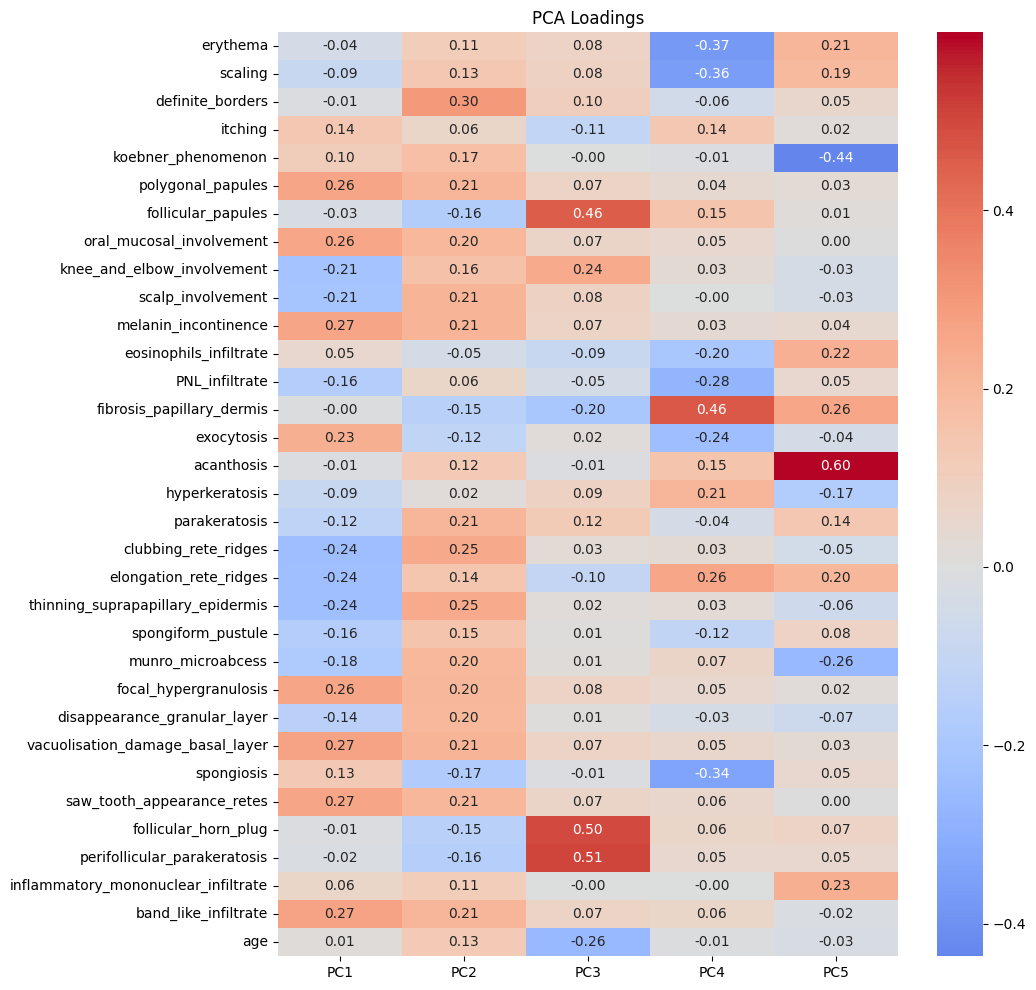

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

loadings_df = pd.DataFrame(
    pca_2.components_.T,
    index=df_features.columns,
    columns=[f'PC{i+1}' for i in range(pca_2.n_components_)]
)

plt.figure(figsize=(10, 12))
sns.heatmap(
    loadings_df,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("PCA Loadings")
plt.show()

In [ ]:
# 7. Провести ФА в соответствии с заявленными гипотезами, вывести факторные нагрузки, сделать визуализацию векторов

In [ ]:
fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(df_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=5, rotation='varimax', rotation_kwargs={})

In [ ]:
fa_loadings = pd.DataFrame(
    fa.loadings_,
    index=df_features.columns,
    columns=[f'Factor{i+1}' for i in range(fa.n_factors)]
)


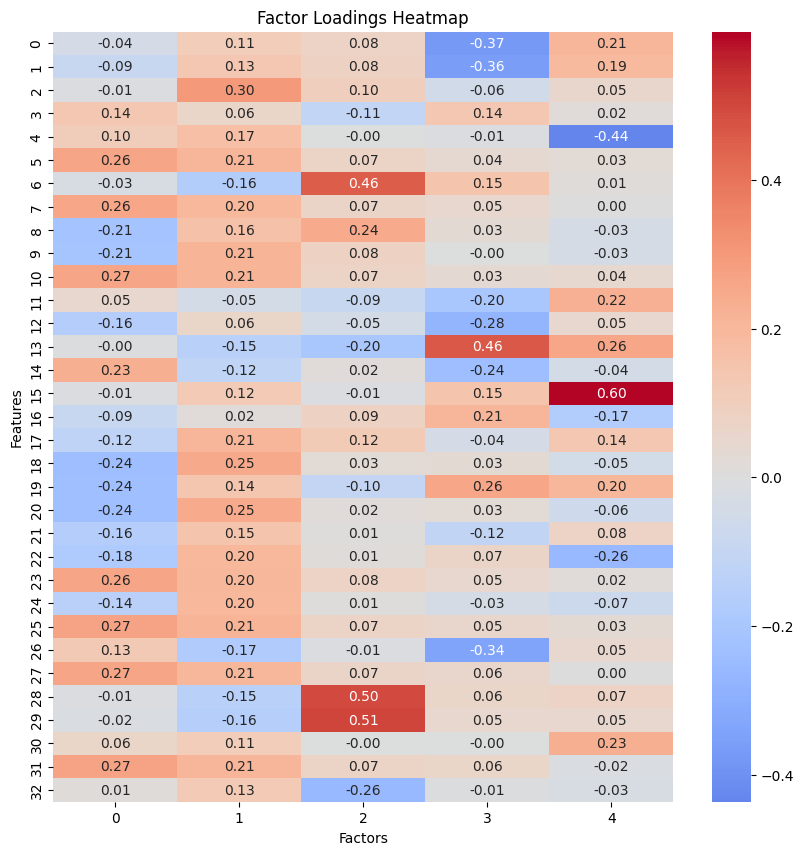

In [ ]:
plt.figure(figsize=(10, 10))

sns.heatmap(
    loadings,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Factor Loadings Heatmap")
plt.xlabel("Factors")
plt.ylabel("Features")
plt.show()

In [ ]:
for col in fa_loadings.columns:
    print(f"\n{col}:")
    print(fa_loadings[col][abs(fa_loadings[col]) > 0.4])


Factor1:
koebner_phenomenon                  0.431082
polygonal_papules                   0.931805
oral_mucosal_involvement            0.905349
melanin_incontinence                0.941969
focal_hypergranulosis               0.926565
vacuolisation_damage_basal_layer    0.957988
saw_tooth_appearance_retes          0.934635
band_like_infiltrate                0.948447
Name: Factor1, dtype: float64

Factor2:
knee_and_elbow_involvement           0.722827
scalp_involvement                    0.737270
exocytosis                          -0.707305
parakeratosis                        0.480233
clubbing_rete_ridges                 0.872816
elongation_rete_ridges               0.728265
thinning_suprapapillary_epidermis    0.849257
spongiform_pustule                   0.426231
munro_microabcess                    0.714062
disappearance_granular_layer         0.525486
spongiosis                          -0.651126
Name: Factor2, dtype: float64

Factor3:
follicular_papules              0.858383
fol

In [ ]:
factor_scores = fa.transform(df_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


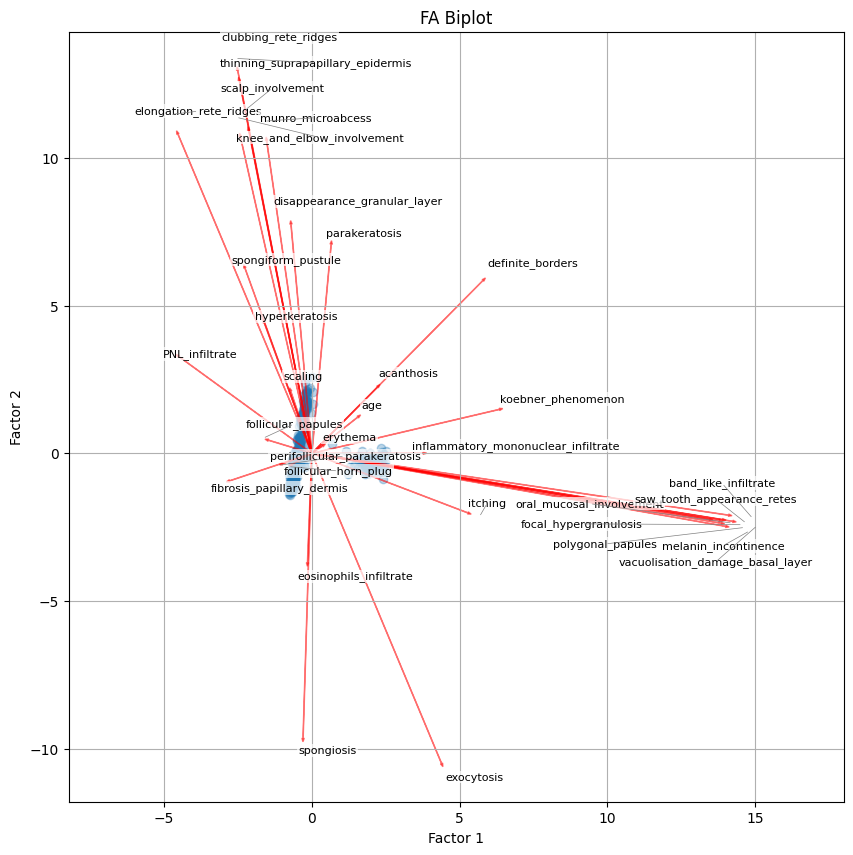

In [ ]:
scale = 15

plt.figure(figsize=(10, 10))

# точки наблюдений
plt.scatter(
    factor_scores[:, 0],
    factor_scores[:, 1],
    alpha=0.3
)

texts = []

# векторы признаков
for i, feature in enumerate(df_features.columns):

    x = fa_loadings.iloc[i, 0] * scale
    y = fa_loadings.iloc[i, 1] * scale

    plt.arrow(
        0, 0,
        x, y,
        color='r',
        alpha=0.5,
        width=0.01,
        head_width=0.08,
        length_includes_head=True
    )

    texts.append(
        plt.text(
            x * 1.05,
            y * 1.05,
            feature,
            fontsize=8,
            bbox=dict(
                facecolor='white',
                alpha=0.7,
                edgecolor='none',
                pad=1
            )
        )
    )

# автораздвижение подписей
adjust_text(
    texts,

    expand_points=(2, 2),
    expand_text=(1.2, 1.2),

    force_text=0.8,
    force_points=0.5,

    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=0.5
    )
)

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")

plt.title("FA Biplot")

plt.grid(True)

plt.axis('equal')

plt.show()

In [ ]:
# 8. сделать LDA, SVD

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=5)
df_lda = lda.fit_transform(df_scaled, df['class'])

In [ ]:
svd = TruncatedSVD(n_components=5)
df_svd = svd.fit_transform(df_scaled)

In [ ]:
# 9. Визуализировать с помощью этих методов признаковое пространство с подкрашенными по меткам классов примерами (для всех методов визуализировать по первым 2м компонентам)

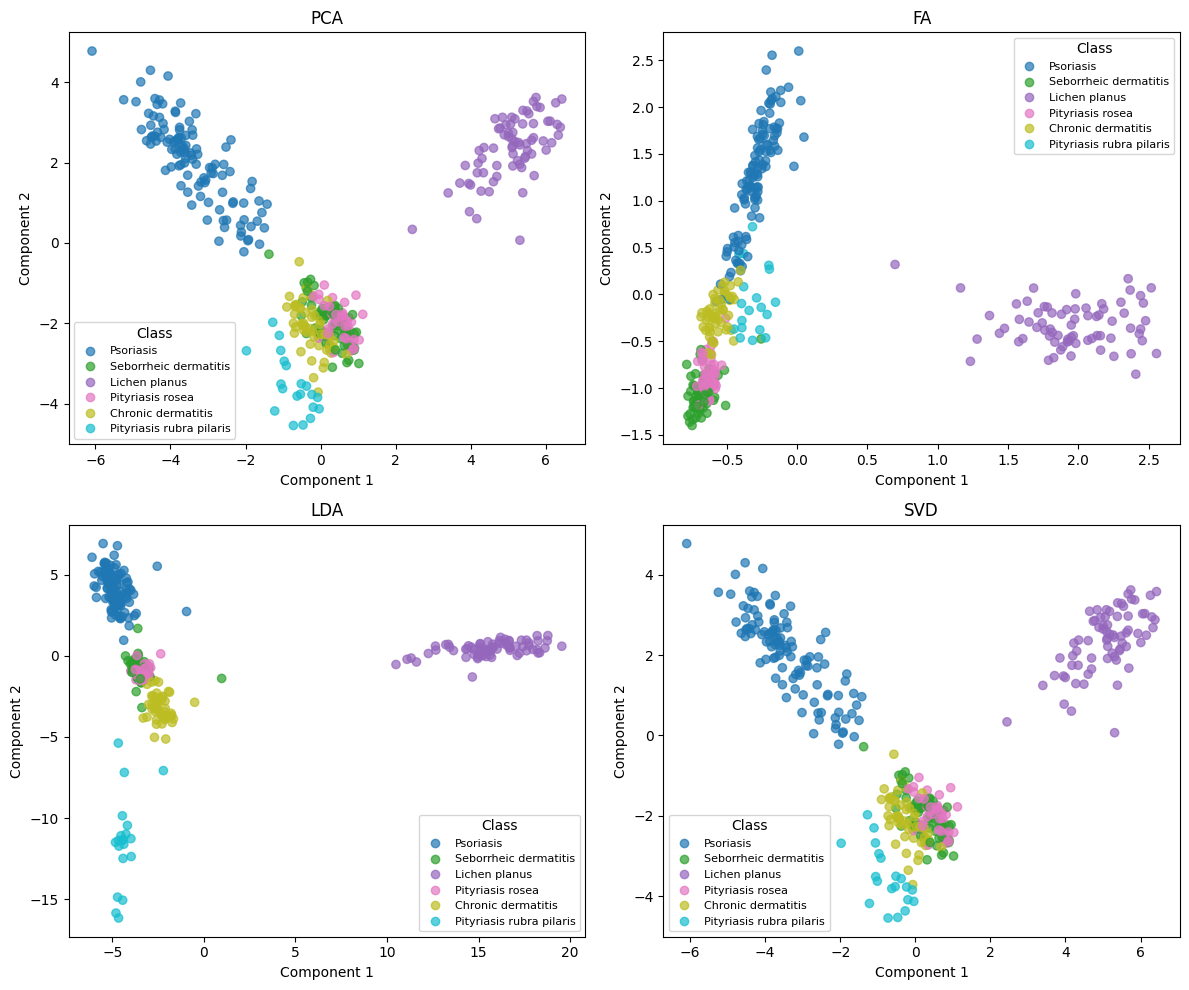

In [ ]:
methods = {
    "PCA": df_pca,
    "FA": factor_scores,
    "LDA": df_lda,
    "SVD": df_svd
}

# словарь меток классов
class_labels = {
    1: "Psoriasis",
    2: "Seborrheic dermatitis",
    3: "Lichen planus",
    4: "Pityriasis rosea",
    5: "Chronic dermatitis",
    6: "Pityriasis rubra pilaris"
}

plt.figure(figsize=(12, 10))

for i, (name, data) in enumerate(methods.items(), 1):

    plt.subplot(2, 2, i)

    scatter = plt.scatter(
        data[:, 0],
        data[:, 1],
        c=df['class'],
        cmap='tab10',
        alpha=0.7
    )

    # создаём legend вручную
    handles = scatter.legend_elements()[0]

    plt.legend(
        handles,
        [class_labels[k] for k in sorted(class_labels.keys())],
        title="Class",
        fontsize=8
    )

    plt.title(name)

    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

plt.tight_layout()

plt.show()

In [ ]:
# 10. Визуализировать с помощью t-SNE

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
df_tsne = tsne.fit_transform(df_scaled)

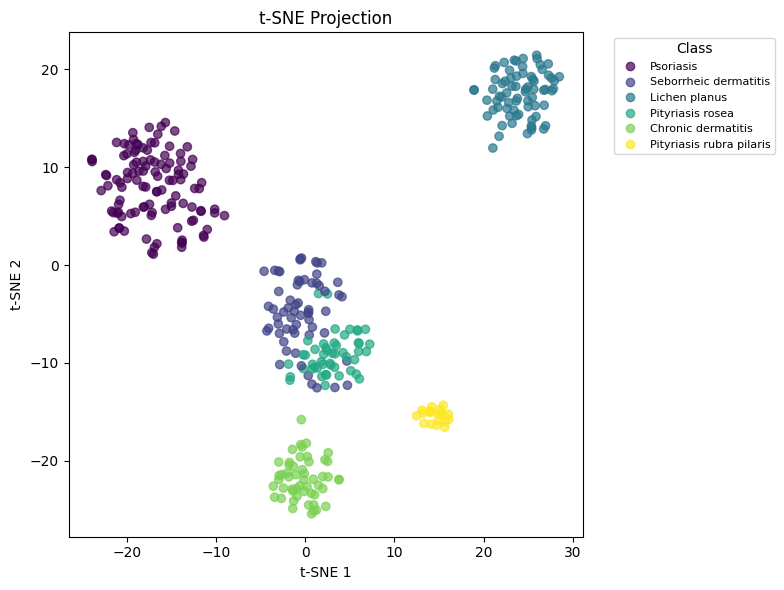

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# метки классов
class_labels = {
    1: "Psoriasis",
    2: "Seborrheic dermatitis",
    3: "Lichen planus",
    4: "Pityriasis rosea",
    5: "Chronic dermatitis",
    6: "Pityriasis rubra pilaris"
}

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_tsne[:, 0],
    df_tsne[:, 1],
    c=df['class'],
    cmap='viridis',
    alpha=0.7
)

# создаём легенду вместо colorbar
handles = scatter.legend_elements()[0]

plt.legend(
    handles,
    [class_labels[k] for k in sorted(class_labels.keys())],
    title="Class",
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("t-SNE Projection")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd
import plotly.express as px

tsne = TSNE(
    n_components=3,
    random_state=42,
    perplexity=30,
    init='pca',
    learning_rate='auto'
)

df_tsne = tsne.fit_transform(df_scaled)

# словарь классов
class_labels = {
    1: "Psoriasis",
    2: "Seborrheic dermatitis",
    3: "Lichen planus",
    4: "Pityriasis rosea",
    5: "Chronic dermatitis",
    6: "Pityriasis rubra pilaris"
}

tsne_df = pd.DataFrame(
    df_tsne,
    columns=['t-SNE 1', 't-SNE 2', 't-SNE 3']
)

# заменяем цифры на названия классов
tsne_df['class'] = df['class'].map(class_labels)

fig = px.scatter_3d(
    tsne_df,
    x='t-SNE 1',
    y='t-SNE 2',
    z='t-SNE 3',
    color='class',
    title='3D t-SNE Projection',
    opacity=0.8
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    legend_title_text='Disease Class'
)

fig.show()

In [ ]:
# 11.  выводы

В ходе лабораторной работы была решена задача снижения размерности и факторного анализа на основе медицинского датасета по дерматологическим заболеваниям, содержащего 6 классов. Данные включали клинические и гистопатологические признаки.

На основе анализа корреляционной матрицы были выдвинуты гипотезы о наличии 4–5  факторов, отражающих различные группы признаков:

Были применены методы снижения размерности и анализа данных:
- PCA
- факторный анализ
- линейный дискриминантный анализ
- сингулярное разложение
- t-SNE

С помощью PCA было установлено, что оптимальное число компонент составляет около 4–5, что подтверждается графиком scree plot.



**3. Интерпретация факторов**

Факторный анализ выявил осмысленные клинико-морфологические группы:

**Фактор 1 (воспалительно-дегенеративный / лихеноидный паттерн)**

Признаки лишая: сильное иммунное воспаление + повреждение глубоких слоёв кожи.

- oral_mucosal_involvement, поражение слизистой рта
- polygonal_papules, полигональные папулы
- melanin_incontinence, недержание меланина
- band_like_infiltrate, ленточный инфильтрат
- saw_tooth_retes, «пилообразные» выросты

Характеризует выраженные иммунные и структурные изменения кожи.

**Фактор 2 (эпидермальные изменения и псориатический паттерн)**

признаки псориаза

- clubbing_rete_ridges, булавовидное утолщение эпидермальных выростов
- elongation_rete_ridges, удлинение эпидермальных выростов
- munro_microabcess, микроабсцессы
- thinning_epidermis, истончение надсосочкового эпидермиса

Связан с гиперпролиферацией эпидермиса.

**Фактор 3 (фолликулярные изменения)**

Нарушение образования рогового слоя именно вокруг волос

- follicular_papules, фолликулярные папулы
- follicular_horn_plug, роговые пробки фолликулов
- perifollicular_parakeratosis, перифолликулярный паракератоз

Отражает фолликулярные заболевания с нарушением кератинизации.

**Фактор 4 (клинические поверхностные признаки)**

внешние признаки воспаления кожи - не конкретная болезнь

- erythema, покраснение
- scaling, шелушение

Отражает внешние проявления воспаления.

**Фактор 5 (структурные изменения дермы) // проблемы с соединительной тканью**

глубокие, хронические и структурные изменения дермы

- fibrosis,
- acanthosis  

Связан с давними более глубокими тканевыми изменениями.